In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from matplotlib.ticker import ScalarFormatter
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance

import compute_metrics as cm
import degrade_profiles as dp

In [17]:
#lines to analyse
lines = ['Fe6173', 'Fe5250', 'Fe6152', 'Fe6271']

#pretty names for plots
line_titles = {
    'Fe6173': 'Fe I 617.3 nm',
    'Fe5250': 'Fe I 525.0 nm',
    'Fe6152': 'Fe I 615.2 nm',
    'Fe6271': 'Fe I 627.1 nm',
}

#wavelengths of lines (nm)
line_wavelengths = {
    'Fe6173': np.loadtxt('../line_creation/data/Fe6173/wl_air.txt'),
    'Fe5250': np.loadtxt('../line_creation/data/Fe5250/wl_air.txt'),
    'Fe6152': np.loadtxt('../line_creation/data/Fe6152/wl_air.txt'),
    'Fe6271': np.loadtxt('../line_creation/data/Fe6271/wl_air.txt'),
}

#rest wavelengths of lines (nm)
line_rest_wavelengths = {
    'Fe6173': 617.33339,
    'Fe5250': 525.02088,
    'Fe6152': 615.16169,
    'Fe6271': 627.12775,
}

#location of results (grid directory)
results_dir = '../grids/solar_inc90/output_data'

#metrics to compute
features = {
    "Equivalent Width [m/s]": cm.compute_equivalent_width,
    "Normalised Line Depth": cm.compute_core_depth,
    "FWHM [m/s]": cm.compute_fwhm,
}

#instrumental resolution to degrade to 
#Original profiles are at R=2,000,000
#Espresso UHR mode = 190,000
resolution = 190000
snr = 1000
n_lines = 10


In [3]:
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],  
    'font.size': 16,                    
    'axes.titlesize': 20,
    'axes.labelsize': 18,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 14,
    'figure.titlesize': 20
})

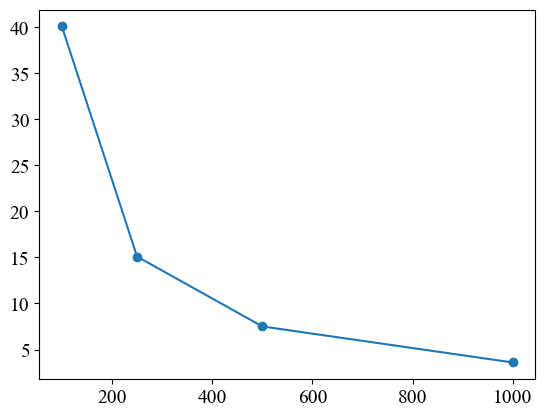

In [4]:
snrs = [1000, 500, 250, 100]

line = 'Fe6173'

Is = np.load(f'{results_dir}/{line}_DI_1000.npy')
Is = [Is[i]/np.max(Is[i]) for i in range(len(Is))]
wl_og = line_wavelengths[line]

#degrade to specified resolution
wl = dp.degrade_and_rebin(wl_og, Is[0], R=resolution)[0]
Is = [dp.degrade_and_rebin(wl_og, I, R=resolution)[1] for I in Is]
mean_Is = np.mean(Is, axis=0)
vel = (wl - np.median(wl)) / np.median(wl) * 299792458 #convert wl to velocity (m/s)

rv_ccfs = np.array([np.real(cm.get_rv(wl, I, mean_Is)) for I in Is])

wl_ext, Is_ext, template = cm.extend_lines(Is, wl, line_rest_wavelengths[line], n_lines=n_lines)

RV_rms = []

for snr in snrs: 
    noisy_Is_ext = dp.add_photon_noise(Is_ext, snr=snr)
    vel = cm.get_ccf(wl_ext, noisy_Is_ext[0], template)[0]
    ccfs = np.array([cm.get_ccf(wl_ext, I, template)[1] for I in noisy_Is_ext])

    rvs_ext = [cm.find_line_core(vel, ccfs[i])[0] for i in range(len(ccfs))] 
    rvs_ext = rvs_ext - np.mean(rvs_ext)

    RV_rms.append(np.std(rvs_ext))

plt.plot(snrs, RV_rms, marker='o')
    

In [5]:
print(RV_rms)

[3.593016053030432, 7.508061790288861, 15.098603005389771, 40.08547082713258]


In [18]:
line = 'Fe6173'

Is = np.load(f'{results_dir}/{line}_DI_1000.npy')
Is = [Is[i]/np.max(Is[i]) for i in range(len(Is))]
wl_og = line_wavelengths[line]

#degrade to specified resolution
wl = dp.degrade_and_rebin(wl_og, Is[0], R=resolution)[0]
Is = [dp.degrade_and_rebin(wl_og, I, R=resolution)[1] for I in Is]
mean_Is = np.mean(Is, axis=0)
vel = (wl - np.median(wl)) / np.median(wl) * 299792458 #convert wl to velocity (m/s)

rv_ccfs = np.array([np.real(cm.get_rv(wl, I, mean_Is)) for I in Is])

wl_ext, Is_ext, template = cm.extend_lines(Is, wl, line_rest_wavelengths[line], n_lines=n_lines)
noisy_Is_ext = dp.add_photon_noise(Is_ext, snr=snr)
vel = cm.get_ccf(wl_ext, noisy_Is_ext[0], template)[0]
ccfs = np.array([cm.get_ccf(wl_ext, I, template)[1] for I in noisy_Is_ext])

# rvs_ext = np.array([np.real(cm.get_rv(wl_ext, noisy_Is_ext[i], template)) for i in range(len(noisy_Is_ext))])

# idx = np.where(np.abs(vel) < 10000)
# vel = vel[idx]
# ccfs = ccfs[:, idx[0]]

# rvs_ext = np.array([np.real(cm.get_rv(vel, ccfs[i], np.mean(ccfs, axis = 0))) for i in range(len(ccfs))])

# bisxs = []
# bisys = []
# widths = []

# for ccf in ccfs:
#     bisx, bisy, width = cm.calculate_line_bisector(vel, ccf, return_width=True)

#     bisxs.append(bisx)
#     bisys.append(bisy)
#     widths.append(width)

    

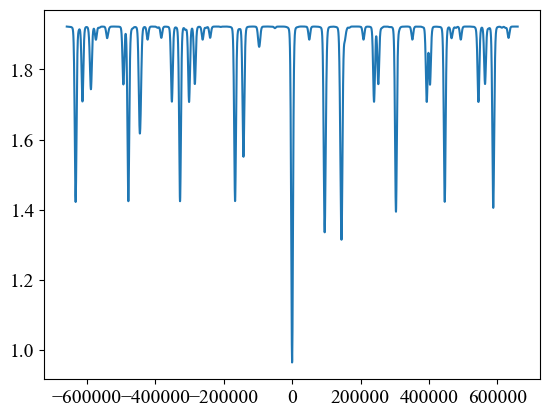

In [19]:
rvs_ext = [cm.find_line_core(vel, ccfs[i])[0] for i in range(len(ccfs))]

plt.plot(vel, np.mean(ccfs, axis=0))

Text(0.5, 1.0, 'Fe6173')

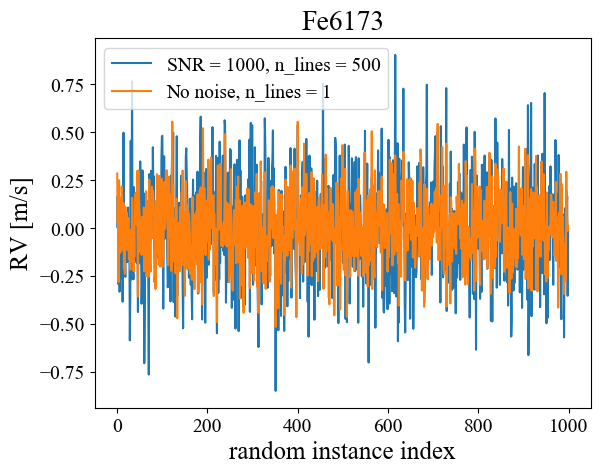

In [9]:

plt.plot(rvs_ext-np.mean(rvs_ext), label = 'SNR = 1000, n_lines = 500')
plt.plot(rv_ccfs-np.mean(rv_ccfs), label = 'No noise, n_lines = 1')

plt.legend()
plt.xlabel('random instance index')
plt.ylabel('RV [m/s]')

plt.title('Fe6173')


In [13]:
print(np.std(rvs_ext))

0.25640271154720423


Text(0, 0.5, 'EW (mean subtracted) [m/s]')

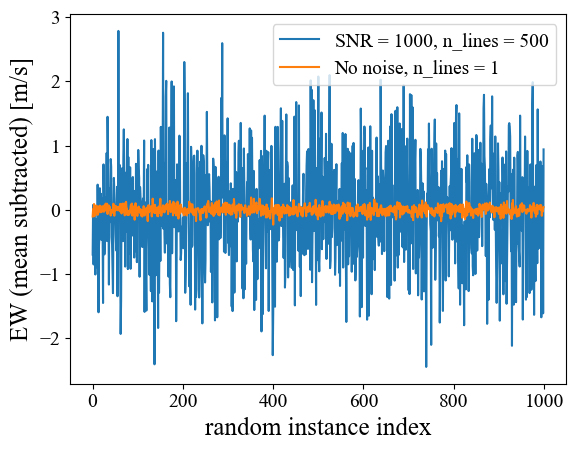

In [10]:
idx = np.where(np.abs(vel) < 10000)
vel = vel[idx]
ccfs = ccfs[:, idx[0]]

ews_ext = [cm.compute_equivalent_width(vel, ccfs[i]/np.max(ccfs[i])) for i in range(len(ccfs))]

c = 299792458

vel_og = (wl - np.median(wl)) / np.median(wl) * c
ews_og = [cm.compute_equivalent_width(vel_og, Is[i]) for i in range(len(Is))]

plt.plot(ews_ext - np.mean(ews_ext), label = 'SNR = 1000, n_lines = 500')
plt.plot(ews_og - np.mean(ews_og), label = 'No noise, n_lines = 1')

plt.legend()
plt.xlabel('random instance index')
plt.ylabel('EW (mean subtracted) [m/s]')

(1000, 3351)


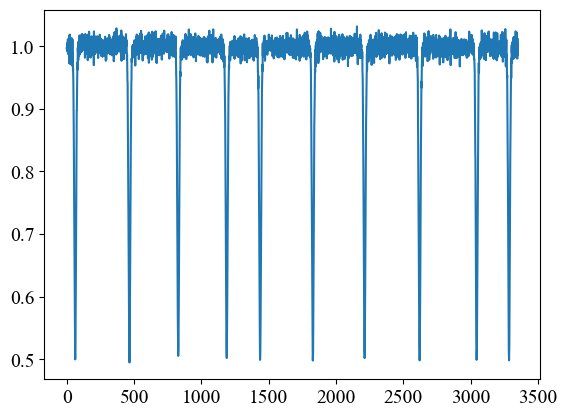

In [28]:
sigma = Is_ext / 100
noise = np.random.normal(0, sigma, Is_ext.shape)

print(sigma.shape)

# plt.plot(noise[0])
plt.plot(Is_ext[0]+noise[0])

Text(0, 0.5, 'Core Depth (mean subtracted)')

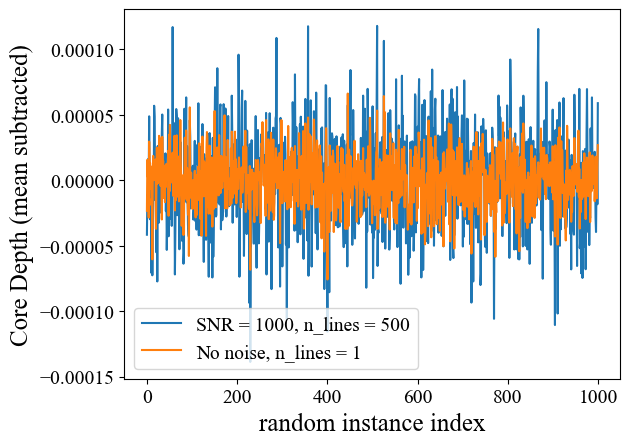

In [11]:
core_depths_ext = [cm.compute_core_depth(vel, ccfs[i]) for i in range(len(ccfs))]
core_depths_og = [cm.compute_core_depth(vel_og, Is[i]) for i in range(len(Is))]

plt.plot(core_depths_ext - np.mean(core_depths_ext), label = 'SNR = 1000, n_lines = 500')
plt.plot(core_depths_og - np.mean(core_depths_og), label = 'No noise, n_lines = 1')
plt.legend()
plt.xlabel('random instance index')
plt.ylabel('Core Depth (mean subtracted)')

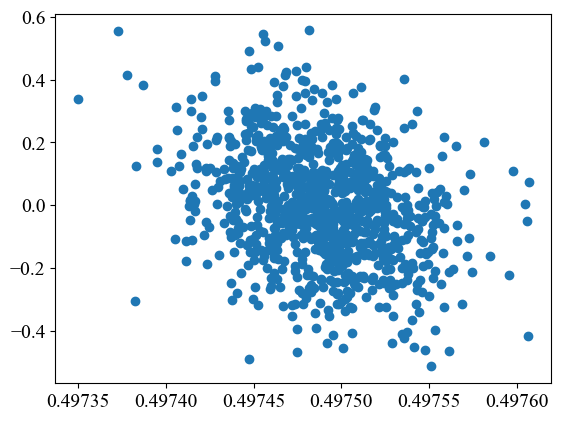

In [12]:
plt.plot(core_depths_ext, rv_ccfs, 'o')

2921.789317216416
3335.094211134804


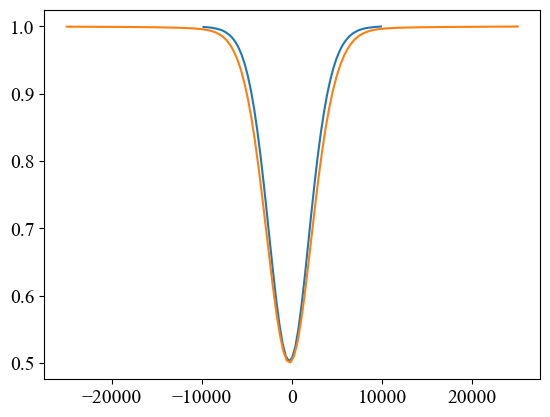

In [44]:
plt.plot(vel, ccfs[0]/np.max(ccfs[0]))
print(cm.compute_equivalent_width(vel, ccfs[0]/np.max(ccfs[0])))
plt.plot(vel_og, Is[0])
print(cm.compute_equivalent_width(vel_og, Is[0]))

(-9850.718478510273, 9850.718478510273)

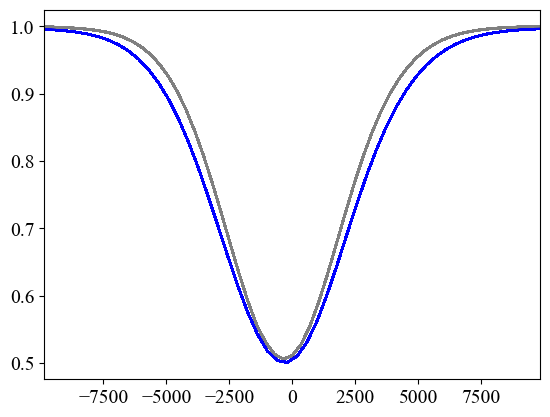

In [60]:
for i in range(1000):
    plt.plot(vel, ccfs[i]/np.max(ccfs[i]), color='gray', alpha=0.3)
    plt.plot(vel_og, Is[i]/np.max(Is[i]), color='blue', alpha=0.3)

plt.xlim(np.min(vel), np.max(vel))

(1000, 50)
Max correlation: -0.077 at 2
R = 0.016


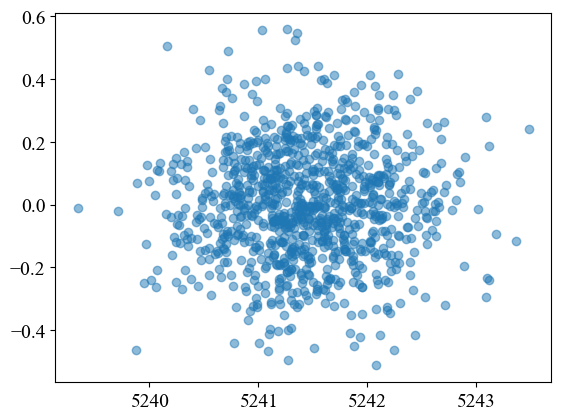

In [42]:
widths = np.array(widths)
print(widths.shape)
Rs = []

for i in range(widths.shape[1]):
    R = np.corrcoef(rv_ccfs, widths[:,i])[0,1]
    Rs.append(R)

idx = np.argmax(np.abs(Rs))
print(f'Max correlation: {Rs[idx]:.3f} at {idx}')


plt.plot(np.mean(widths, axis=1), rv_ccfs, 'o', alpha=0.5)
R = np.corrcoef(np.mean(widths, axis=1), rv_ccfs)[0,1]
print(f'R = {R:.3f}')

In [27]:
np.save('bisxs.npy', np.array(bisxs))
np.save('bisys.npy', np.array(bisys))
np.save('rvs_og.npy', rv_ccfs)


=== Processing Fe6173 ===


KeyboardInterrupt: 

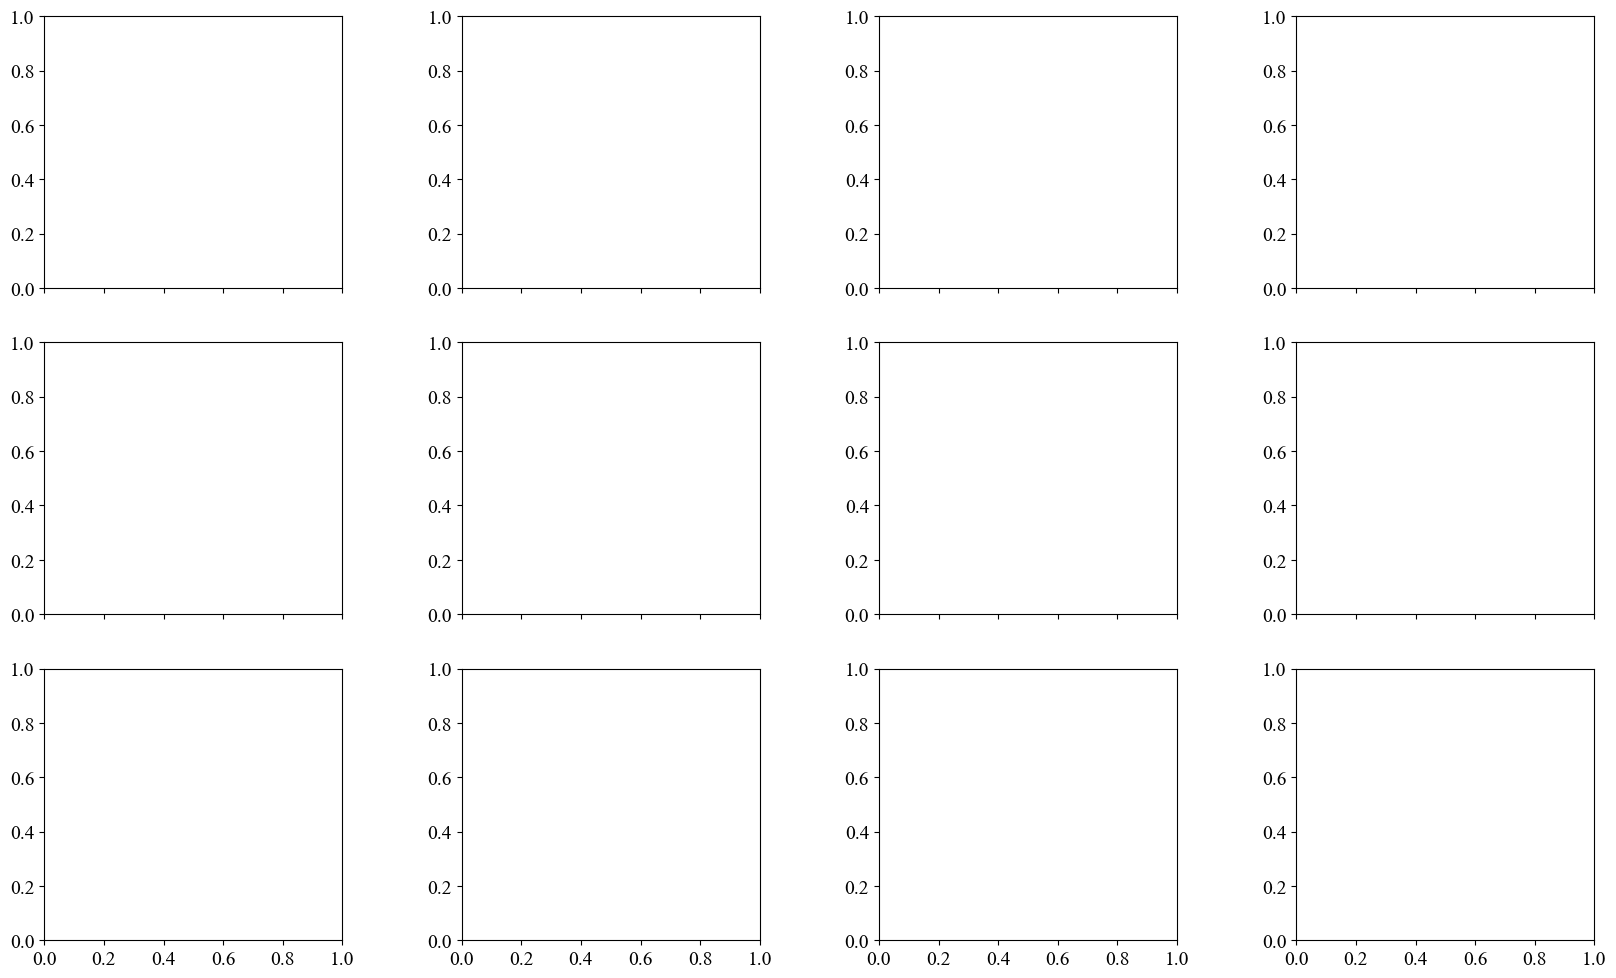

In [10]:
fig, axes = plt.subplots(3, 4, figsize=(20, 12), sharex=True)
plt.subplots_adjust(hspace=0.2, wspace=0.4)

hb = None  

for col, line in enumerate(lines):
    print(f"\n=== Processing {line} ===")
    Is = np.load(f'{results_dir}/{line}_DI_1000.npy')
    Is = [Is[i]/np.max(Is[i]) for i in range(len(Is))]
    wl_og = line_wavelengths[line]

    #degrade to specified resolution
    wl = dp.degrade_and_rebin(wl_og, Is[0], R=resolution)[0]
    Is = [dp.degrade_and_rebin(wl_og, I, R=resolution)[1] for I in Is]
    mean_Is = np.mean(Is, axis=0)
    vel = (wl - np.median(wl)) / np.median(wl) * 299792458 #convert wl to velocity (m/s)

    rv_ccfs = np.array([np.real(cm.get_rv(wl, I, mean_Is)) for I in Is])

    wl_ext, Is_ext, template = cm.extend_lines(Is, wl, line_rest_wavelengths[line], n_lines=n_lines)
    noisy_Is_ext = dp.add_photon_noise(Is_ext, snr=snr)
    vel = cm.get_ccf(wl_ext, noisy_Is_ext[0], template)[0]
    ccfs = np.array([cm.get_ccf(wl_ext, I, template)[1] for I in noisy_Is_ext])

    for row, (fname, ffunc) in enumerate(features.items()):
        feats = np.array([ffunc(vel, ccf) for ccf in ccfs]).reshape(-1, 1)

        model = LinearRegression()
        model.fit(feats, rv_ccfs)
        rv_pred = model.predict(feats)

        rv_corrected = rv_ccfs - rv_pred
        rms_before = np.std(rv_ccfs, ddof=1)
        rms_after = np.std(rv_corrected, ddof=1)
        scatter_red = (rms_before - rms_after) / rms_before * 100
        R = np.corrcoef(feats.flatten(), rv_ccfs)[0, 1]

        ax = axes[row, col]
        hb = ax.hexbin(
            rv_ccfs, feats.flatten(),
            gridsize=30, cmap="RdPu_r",
            extent=(-0.75, 0.6, feats.flatten().min(), feats.flatten().max()),
            vmin=0,  
            vmax = 30
        )

        ax.plot(rv_pred, feats, '--', color="lightgreen", label="Fit")
        ax.set_title(f"{line_titles[line]}" if row == 0 else "")
        if col == 0:
            ax.set_ylabel(f"{fname}")
        ax.set_xlabel("RV [m/s]" if row == 2 else "")

        textstr = f"R = {R:.3f}\nScatter ↓ {scatter_red:.1f}%"
        ax.text(0.05, 0.25, textstr, transform=ax.transAxes,
                fontsize=16, verticalalignment='top',
                bbox=dict(boxstyle="round", facecolor='lightgreen', edgecolor='black'))

# one shared colorbar for the whole figure
cbar = fig.colorbar(hb, ax=axes, orientation="vertical", shrink=0.8)
cbar.set_label("Counts")

for ax in axes.flat:
    ax.xaxis.set_major_formatter(ScalarFormatter(useOffset=False))
    ax.ticklabel_format(style='plain', axis='x')
    ax.yaxis.set_major_formatter(ScalarFormatter(useOffset=False))
    ax.ticklabel_format(style='plain', axis='y')

#plt.savefig('output_plots/feature_vs_RV_all_lines.png', bbox_inches='tight', dpi=300)
plt.show()


In [8]:
print(n_lines, snr, resolution)
lines = ['Fe6173']

n_lines = 10

1 100000 190000



=== Processing Fe6173 ===


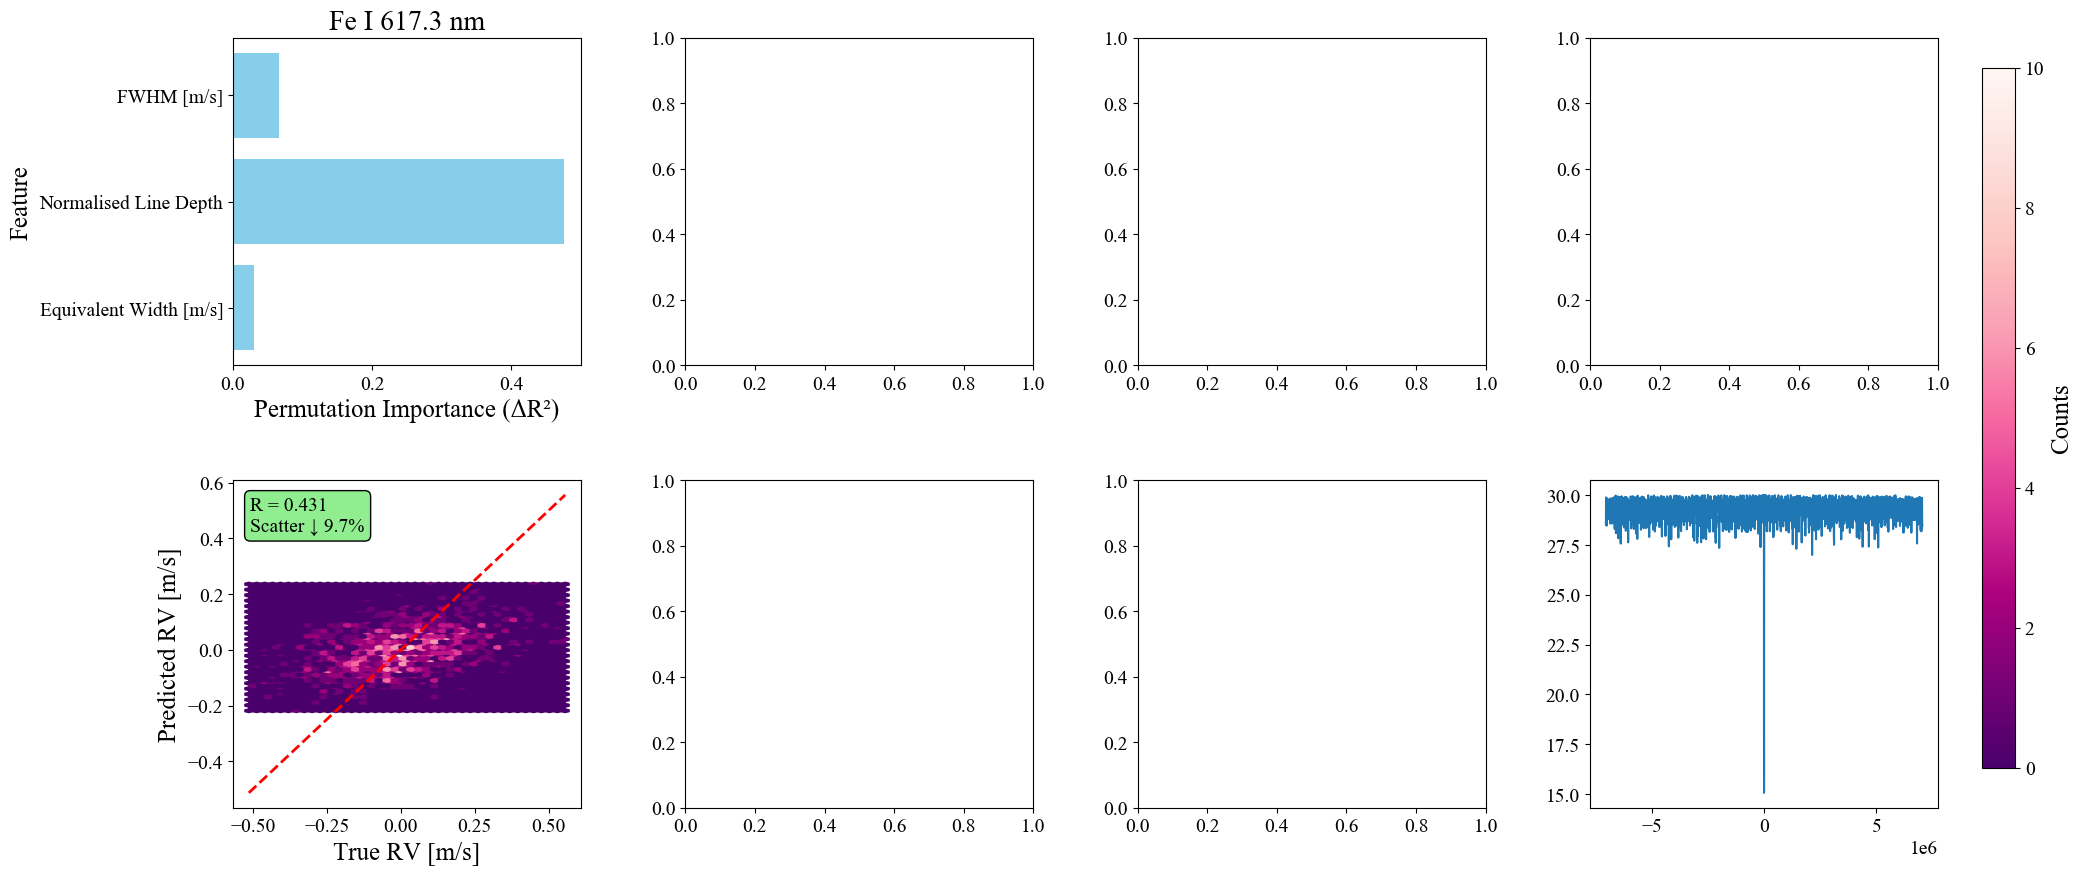

In [18]:

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
plt.subplots_adjust(hspace=0.35, wspace=0.3)

lines = ['Fe6173']

hb = None 

for col, line in enumerate(lines):
    print(f"\n=== Processing {line} ===")
    Is_test = np.load(f'{results_dir}/{line}_DI_1000.npy')
    Is_train = np.load(f'{results_dir}/{line}_DI_1000_train.npy')

    #normalise
    Is_test = [Is_test[i]/np.max(Is_test[i]) for i in range(len(Is_test))]
    Is_train = [Is_train[i]/np.max(Is_train[i]) for i in range(len(Is_train))]

    wl_og = line_wavelengths[line]

    # degrade to specified resolution
    wl = dp.degrade_and_rebin(wl_og, Is_train[0], R=resolution)[0]
    Is_train = [dp.degrade_and_rebin(wl_og, I, R=resolution)[1] for I in Is_train]
    Is_test = [dp.degrade_and_rebin(wl_og, I, R=resolution)[1] for I in Is_test]

    mean_Is_train = np.mean(Is_train, axis=0)
    mean_Is_test = np.mean(Is_test, axis=0)

    y_train = np.array([np.real(cm.get_rv(wl, I, mean_Is_train)) for I in Is_train])
    y_test = np.array([np.real(cm.get_rv(wl, I, mean_Is_train)) for I in Is_test])

    concatenated_Is = np.concatenate((Is_train, Is_test), axis=0)
    wl_ext, concatenated_Is_ext, template = cm.extend_lines(concatenated_Is, wl, line_rest_wavelengths[line], n_lines=n_lines)

    wl_ext_train = wl_ext
    wl_ext_test = wl_ext

    Is_ext_train = concatenated_Is_ext[:len(Is_train)]
    Is_ext_test = concatenated_Is_ext[len(Is_train):] 

    template_train = template
    template_test = template

    noisy_Is_ext_train = dp.add_photon_noise(Is_ext_train, snr=snr)
    noisy_Is_ext_test = dp.add_photon_noise(Is_ext_test, snr=snr)

    vel = cm.get_ccf(wl_ext_train, noisy_Is_ext_train[0], template_train)[0]
    ccfs_train = np.array([cm.get_ccf(wl_ext_train, I, template_train)[1]for I in noisy_Is_ext_train])
    ccfs_test = np.array([cm.get_ccf(wl_ext_test, I, template_test)[1] for I in noisy_Is_ext_test])

    # y_train = np.array([cm.find_line_core(vel, ccfs_train[i])[0] for i in range(len(ccfs_train))])
    # y_test = np.array([cm.find_line_core(vel, ccfs_test[i])[0] for i in range(len(ccfs_test))])

    # m = np.mean(y_train)

    # y_train = y_train - m
    # y_test = y_test - m

    # idx = np.where(np.abs(vel) < 20000)
    # vel = vel[idx]
    # ccfs_train = ccfs_train[:, idx[0]]  
    # ccfs_test = ccfs_test[:, idx[0]]

    plt.plot(vel, np.abs(ccfs_train[0]))

    # === Feature matrix ===
    all_feats_train = np.column_stack([
        [ffunc(vel, ccf) for ccf in ccfs_train] for _, ffunc in features.items()
    ])

    all_feats_test = np.column_stack([
        [ffunc(vel, ccf) for ccf in ccfs_test] for _, ffunc in features.items()
    ])

    feat_names = list(features.keys())

    # === Scale features ===
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(all_feats_train)
    X_test_scaled = scaler.transform(all_feats_test)

    # === Train regression ===
    model = LinearRegression()
    model.fit(X_train_scaled, y_train)
    
    # Predict
    y_pred = model.predict(X_test_scaled)

    # === Metrics ===
    R = np.corrcoef(y_test, y_pred)[0, 1]
    rms_before = np.std(y_test, ddof=1)
    rms_after = np.std(y_test - y_pred, ddof=1)
    scatter_red = (rms_before - rms_after) / rms_before * 100

    # === Row 1: Feature importance (permutation importance) ===
    result = permutation_importance(model, X_test_scaled, y_test, n_repeats=100, random_state=42)
    importances = result.importances_mean

    ax1 = axes[0, col]
    ax1.barh(feat_names, importances, color="skyblue")
    ax1.set_title(line_titles[line])
    if col == 0:
        ax1.set_ylabel("Feature")
    else:
        ax1.set_yticklabels([])  # hide redundant labels
    ax1.set_xlabel("Permutation Importance (ΔR²)")

    # === Row 2: Predicted vs True RV ===
    ax2 = axes[1, col]
    hb = ax2.hexbin(y_test, y_pred, gridsize=40, cmap="RdPu_r")
    ax2.plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             'r--', lw=2)
    ax2.set_xlabel("True RV [m/s]")
    if col == 0:
        ax2.set_ylabel("Predicted RV [m/s]")

    # Green annotation box
    textstr = f"R = {R:.3f}\nScatter ↓ {scatter_red:.1f}%"
    ax2.text(0.05, 0.95, textstr, transform=ax2.transAxes,
             fontsize=14, verticalalignment='top',
             bbox=dict(boxstyle="round", facecolor='lightgreen', edgecolor='black'))

# === Shared colorbar outside the grid ===
cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])  # [left, bottom, width, height]
cbar = fig.colorbar(hb, cax=cbar_ax)
cbar.set_label("Counts")

# plt.savefig("output_plots/rv_prediction_summary_permutation.png", dpi=300, bbox_inches="tight")
plt.show()


/tmp/ipykernel_1499922/467788578.py:80: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])  # make space for colorbar


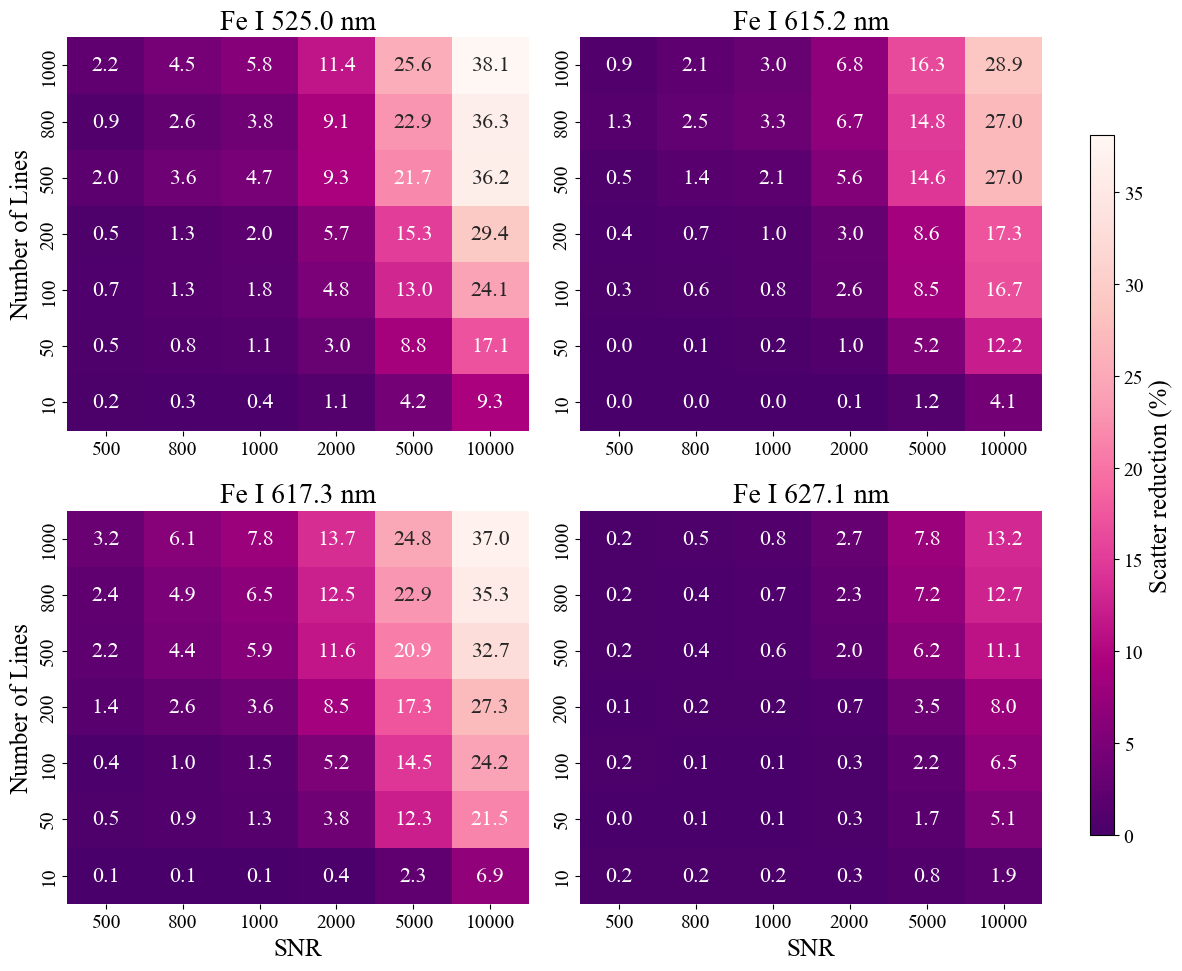

In [30]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# === Load results ===
with open("scatter_results_R190000_photon_noise.json", "r") as f:
    results = json.load(f)

# Extract all line names dynamically
all_lines = set()
for entry in results:
    all_lines.update(entry["scatter_red"].keys())
all_lines = sorted(list(all_lines))

# Convert JSON into a DataFrame per line
dfs = {line: [] for line in all_lines}

for entry in results:
    snr = entry["snr"]
    n_lines = entry["n_lines"]
    for line, val in entry["scatter_red"].items():
        dfs[line].append({
            "snr": snr,
            "n_lines": n_lines,
            "scatter_red": val
        })

# === Plot one heatmap per line ===
n_lines_sorted = sorted({e["n_lines"] for e in results}, reverse=True)
snr_sorted = sorted({e["snr"] for e in results})

ncols = 2
nrows = 2

fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 5*nrows), squeeze=False)

# --- set your vmin/vmax here ---
vmin, vmax = 0, 38.1  # example values — replace with your actual range

# store the last heatmap for colorbar reference
last_hm = None

for i, line in enumerate(all_lines):
    ax = axes.flat[i]
    df_line = pd.DataFrame(dfs[line])
    heatmap_data = df_line.pivot_table(
        index="n_lines", columns="snr", values="scatter_red"
    ).reindex(index=n_lines_sorted, columns=snr_sorted)

    #disable axes labels for inner plots
    heatmap_data.index.name = None
    heatmap_data.columns.name = None
    
    # disable individual colorbars
    hm = sns.heatmap(
        heatmap_data,
        annot=True, fmt=".1f", cmap="RdPu_r",
        vmin=vmin, vmax=vmax,
        cbar=False,  # no individual colorbars
        ax=ax
    )
    ax.set_title(f"{line_titles.get(line, line)}")
    last_hm = hm  # store handle to use for colorbar later

axes[0,0].set_ylabel("Number of Lines")
axes[1,0].set_ylabel("Number of Lines")
axes[1,0].set_xlabel("SNR")
axes[1,1].set_xlabel("SNR")

# Hide unused subplots (if any)
for j in range(i + 1, len(axes.flat)):
    fig.delaxes(axes.flat[j])

# --- single shared colorbar on the right ---
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
fig.colorbar(last_hm.collections[0], cax=cbar_ax, label='Scatter reduction (%)')

plt.tight_layout(rect=[0, 0, 0.9, 1])  # make space for colorbar
plt.show()
